<h1>A: Identification of Candidate Datasets</h1>

To begin this project I explored three main datasets based on their relevance to my research interest of OT/Critical Infrastructure Cybersecurity, ensuring that each has applicability to at least one topic from our class:

- **Western US Power Grid Network Dataset**
  - **Dataset Name and Source:** Western US Power Grid, available from the Network Data Repository (original from D. Watts and S. Strogatz, 1998). Downloadable at https://networkrepository.com/power-US-Grid.php.
  - **Course Topic Alignment:** Graph mining, including PageRank for node importance (e.g., identifying critical substations) and community detection for sector clustering.
  - **Potential Beyond-Course Techniques:** Graph neural networks (GNNs) for predictive modeling of cascading failures or vulnerability propagation.
  - **Dataset Size and Structure:** 4,941 nodes (generators, transformers, substations) and 6,594 undirected edges (power lines), forming a sparse graph with density ~0.00054.
  - **Data Types:** Graph adjacency lists or matrices; nodes include location metadata, edges represent connections without weights.
  - **Target Variable(s):** None (unsupervised; suitable for pattern discovery).
  - **Licensing or Usage Constraints:** Public for research; requires citation of the repository (e.g., Rossi and Ahmed, 2015). No restrictions on non-commercial use.

- **Electric Transmission System Cyber Attack Dataset**
  - **Dataset Name and Source:** Power System Datasets (cyber attack focus), created by Tommy Morris et al. at the University of Alabama in Huntsville (UAH) in collaboration with Oak Ridge National Laboratory (ORNL). Available at https://sites.google.com/a/uah.edu/tommy-morris-uah/ics-data-sets.
  - **Course Topic Alignment:** Anomaly detection in streams or logs, using clustering to group attack behaviors.
  - **Potential Beyond-Course Techniques:** Autoencoder-based anomaly detection for unsupervised feature learning on high-dimensional logs.
  - **Dataset Size and Structure:** Comprises 37 scenarios across three subsets (2-class, 3-class, multi-class), with thousands of instances per scenario (e.g., ~10,000–50,000 rows in samples); structured as time-series logs with 128 features.
  - **Data Types:** Synchrophasor measurements (e.g., voltage magnitudes, phase angles, frequency), network logs (Snort alerts), relay logs; temporal with timestamps.
  - **Target Variable(s):** Labels for normal, disturbance, control, and cyber attack events (e.g., relay manipulation, data injection).
  - **Licensing or Usage Constraints:** For research; requires citation of related papers (e.g., Pan et al., 2015). No explicit license, but public domain implied for academic use.

- **Cyber Operations Tracker Dataset**
  - **Dataset Name and Source:** Cyber Operations Tracker, maintained by the Council on Foreign Relations (CFR). Available at https://www.cfr.org/cyber-operations (downloadable as CSV or browsable).
  - **Course Topic Alignment:** Text mining on incident descriptions, using embeddings for similarity analysis of attack patterns.
  - **Potential Beyond-Course Techniques:** Topic modeling (e.g., LDA) or transformer-based embeddings for advanced sentiment or entity extraction in threat reports.
  - **Dataset Size and Structure:** Over 200 state-sponsored incidents since 2005, with ~76 in 2019 alone; tabular structure with fields per incident.
  - **Data Types:** Text descriptions of attacks, dates, actors (e.g., nation-states like China, Russia), victims (e.g., US energy sector), and types (e.g., espionage, disruption).
  - **Target Variable(s):** Categorical labels for incident types (e.g., sabotage on critical infra); suitable for classification.
  - **Licensing or Usage Constraints:** Open-source; encourages contributions. Public use allowed with attribution to CFR.

<h1>B: Comparative Analysis of Datasets</h1>

<style>
  .table-wrapper {
    overflow-x: auto; /* Adds horizontal scroll if table overflows */
    width: 100%; /* Fills the full page width */
    max-width: 100%; /* Ensures it doesn't exceed the viewport */
  }
  table {
    width: 100%; /* Table spans the wrapper fully */
    table-layout: fixed; /* Locks column widths to prevent expansion */
    border-collapse: collapse;
  }
  th, td {
    border: 1px solid black;
    padding: 8px;
    word-wrap: break-word; /* Wraps long words */
    overflow-wrap: break-word; /* Modern wrapping for better compatibility */
    text-align: left;
    vertical-align: top; /* Aligns text to top for better readability */
  }
  th {
    background-color: #f2f2f2;
  }
  /* Column widths: Distributed to shrink and balance */
  th:nth-child(1), td:nth-child(1) { width: 15%; } /* Dimension - Narrowest */
  th:nth-child(2), td:nth-child(2) { width: 28%; } /* Western US Power Grid */
  th:nth-child(3), td:nth-child(3) { width: 28%; } /* Electric Transmission System */
  th:nth-child(4), td:nth-child(4) { width: 29%; } /* Cyber Operations Tracker - Slight extra for balance */
</style>

<div class="table-wrapper">
  <table>
    <tr>
      <th>Dimension</th>
      <th>Western US Power Grid Network</th>
      <th>Electric Transmission System Cyber Attack Dataset</th>
      <th>Cyber Operations Tracker</th>
    </tr>
    <tr>
      <td><strong>Supported Data Mining Tasks</strong></td>
      <td>Graph mining (course: PageRank,<br> community detection);<br> external: GNNs for fault prediction.</td>
      <td>Anomaly detection (course: clustering attacks);<br> external: autoencoders for feature extraction.</td>
      <td>Text mining (course: embeddings);<br> external: topic modeling for threat trends.</td>
    </tr>
    <tr>
      <td><strong>Data Quality Issues</strong></td>
      <td>Sparse graph with disconnected components;<br> no timestamps, limiting temporal analysis.<br> Potential outdated topology (1998 origin).</td>
      <td>Possible simulation artifacts (e.g., unintended patterns in logs);<br> missing values in some logs;<br> imbalanced classes (~78% normal vs. 22% attack).</td>
      <td>Noisy text (inconsistent descriptions);<br> incomplete coverage due to public-only data;<br> reporting delays.</td>
    </tr>
    <tr>
      <td><strong>Algorithmic Feasibility</strong></td>
      <td>Manageable for Apriori on subgraphs or GNNs without Spark<br> (small size: 4.9K nodes);<br> scalable for community detection.</td>
      <td>Feasible for anomaly algorithms on mid-size data;<br> sequential mining possible on timestamps<br> but may require distributed computing for full logs.</td>
      <td>Text processing scalable (200+ entries);<br> topic modeling efficient,<br> but transformers may need GPU for embeddings.</td>
    </tr>
    <tr>
      <td><strong>Bias Considerations</strong></td>
      <td>Geographic bias (Western US only);<br> underrepresents modern OT integrations like renewables.</td>
      <td>Simulation bias (lab-based, not fully real-world);<br> overemphasis on specific attacks (e.g., relay manipulation).</td>
      <td>Reporting bias (focus on high-profile US incidents);<br> underrepresentation of undetected or non-state attacks.</td>
    </tr>
    <tr>
      <td><strong>Ethical Considerations</strong></td>
      <td>Analysis could reveal vulnerabilities in real grids,<br> risking misuse; power dynamics involve utilities vs. public<br> (e.g., blackout impacts on underserved areas).<br> No harm if anonymized.</td>
      <td>Simulating attacks might normalize threats;<br> employer-employee dynamics in data collection<br> (lab vs. field workers).<br> Potential to aid defenders without harming.</td>
      <td>Exposes state actors, potentially escalating geopolitics;<br> social dynamics include government vs. private sector privacy.<br> Analysis promotes awareness without direct harm.</td>
    </tr>
  </table>
</div>

<h1>C: Dataset Selection</h1>

The Electric Transmission System Cyber Attack Dataset was selected as it directly supports anomaly detection through labeled logs of cyber events in US power Operational Technology (OT).

This style of dataset, enables beyond-course techniques like autoencoders for handling high-dimensional data and for detecting subtle anomalies. Additionally the specific focus on OT allows for the discovery of domain specific attacks like relay manipulations. Lastly, it is US-focused, and simulated from real systems due to MSU/ORNL collaboration, aligning with my research emphasis on national infrastructure.

Trade-offs:
- Lacks natural text components for embeddings or frequent itemsets in transactions.
- Limited supervised opportunities beyond anomalies; simulation may not capture all real-world biases.
- No graph structure, reducing applicability to community detection.

<h1>D: Exploratory Data Analysis</h1>

Extracted Files: ['data1 Sampled Scenarios.csv.arff', 'data10 Sampled Scenarios.csv.arff', 'data11 Sampled Scenarios.csv.arff', 'data12 Sampled Scenarios.csv.arff', 'data13 Sampled Scenarios.csv.arff', 'data14 Sampled Scenarios.csv.arff', 'data15 Sampled Scenarios.csv.arff', 'data2 Sampled Scenarios.csv.arff', 'data3 Sampled Scenarios.csv.arff', 'data4 Sampled Scenarios.csv.arff', 'data5 Sampled Scenarios.csv.arff', 'data6 Sampled Scenarios.csv.arff', 'data7 Sampled Scenarios.csv.arff', 'data8 Sampled Scenarios.csv.arff', 'data9 Sampled Scenarios.csv.arff']
Dataset shape: (4966, 129)
   R1-PA1:VH     R1-PM1:V  R1-PA2:VH     R1-PM2:V   R1-PA3:VH     R1-PM3:V  \
0  70.399324  127673.0908 -49.572308  127648.0176 -169.578319  127723.2374   
1  73.688102  130280.7109 -46.300719  130255.6377 -166.278082  130355.9307   
2  73.733939  130305.7842 -46.254883  130280.7109 -166.232245  130381.0040   
3  74.083443  130581.5902 -45.899649  130556.5169 -165.882741  130656.8100   
4  74.553268  13108

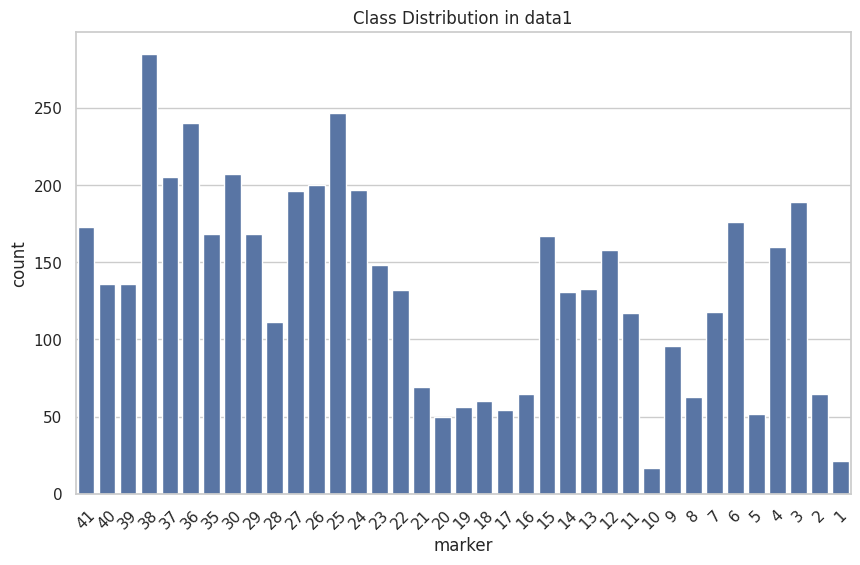

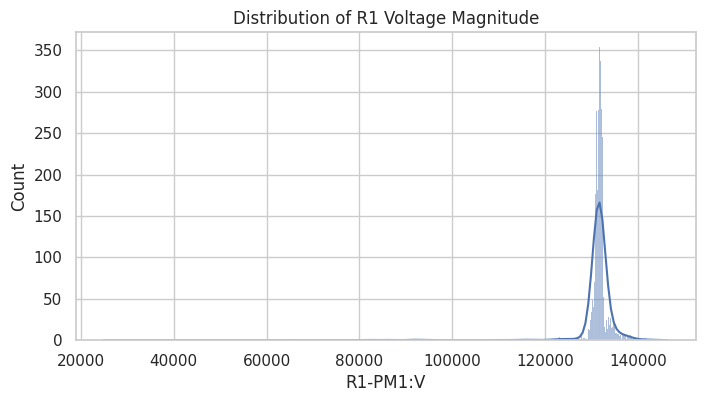

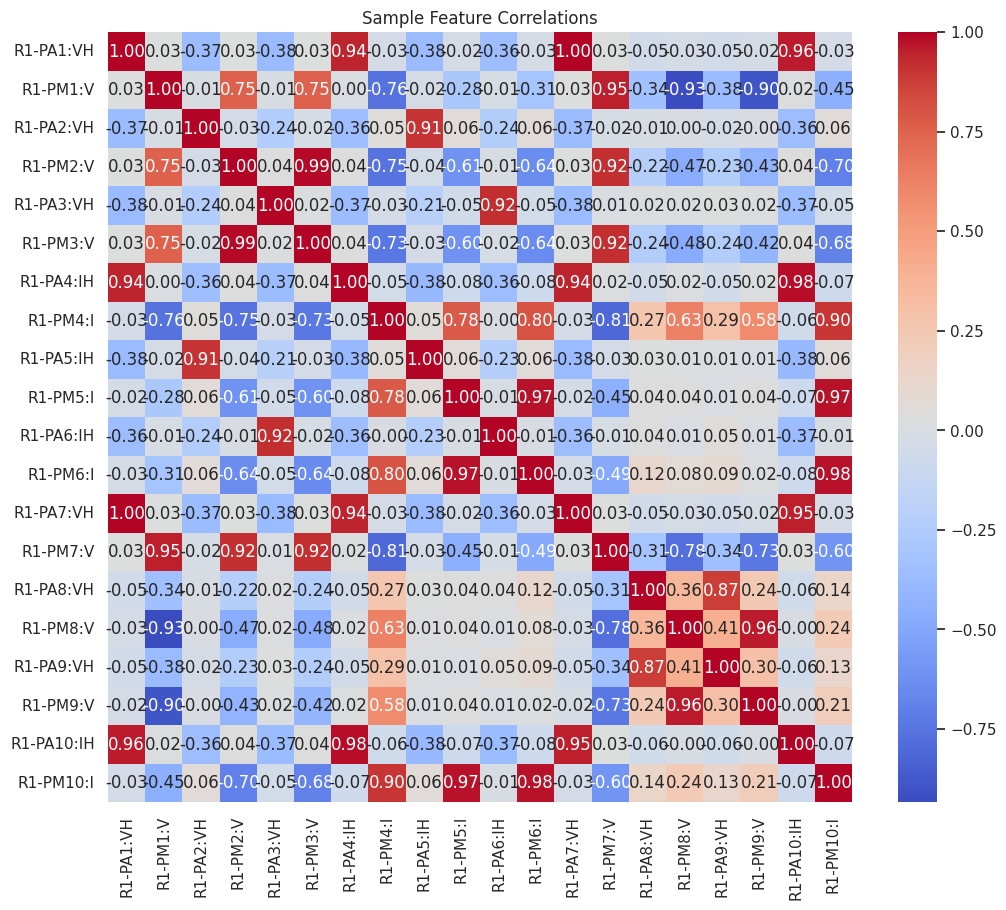

/tmp/ipython-input-1375403804.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['time_proxy'] = df.index  # If no timestamp


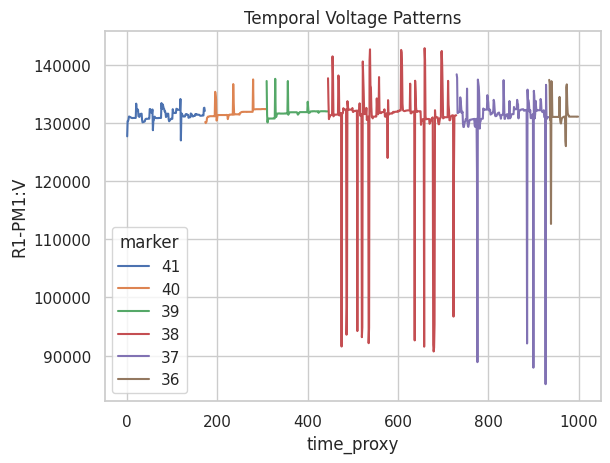

Full Shape: (78377, 129)


In [12]:
# Imports: Centralized for modularity and efficiency
import os
import glob
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.impute import SimpleImputer
from scipy import stats
!pip install py7zr  # Install if needed; lightweight for .7z extraction
import py7zr

# Section 1: Download and Extract Dataset (if not present) ###############################################################
# Purpose: Automate fetching the multiclass dataset; uses HTTP link with fallback checks.
url = 'http://www.ece.uah.edu/~thm0009/icsdatasets/multiclass.7z'
archive_path = 'multiclass.7z'
extract_dir = 'PowerSystemDataset'

if not os.path.exists(archive_path):
    urllib.request.urlretrieve(url, archive_path)  # Download via stdlib for simplicity

if not os.path.exists(extract_dir):
    with py7zr.SevenZipFile(archive_path, mode='r') as z:
        z.extractall(extract_dir)  # Extract all ARFF files to directory

# Inspect extracted files for verification
print("Extracted Files:", sorted(os.listdir(extract_dir)))  # Expected: 15 ARFF files (data1 to data15)

# Section 2: Load Sample File ('data1') for Initial EDA ##################################################################
# Purpose: Load ARFF, decode bytes, and print basics; focuses on 'data1' as representative sample.
arff_path = os.path.join(extract_dir, 'data1 Sampled Scenarios.csv.arff')  # Adjust filename if needed
data, meta = arff.loadarff(arff_path)
df = pd.DataFrame(data)

# Decode byte strings (ARFF artifact)
for col in df.select_dtypes([object]).columns:
    df[col] = df[col].str.decode('utf-8')

# Basics: Shape, head, info, summary stats (sample features)
print(f"Dataset shape: {df.shape}")
print(df.head())
print(df.info())
print(df[['R1-PA1:VH', 'R1-PM1:V', 'control_panel_log4', 'marker']].describe())  # Voltage, angle, log, label

# Unique markers and proportions
print("Unique Markers:", sorted(df['marker'].unique()))
print("Marker Proportions:\n", df['marker'].value_counts(normalize=True))

# Section 3: Data Cleaning ################################################################################################
# Purpose: Check/impute missings, detect outliers; dataset is simulation-clean, but verifies.
missing = df.isna().sum()
print("Missings:", missing[missing > 0])  # Expected: None or minimal

num_cols = df.select_dtypes(include='number').columns.drop('marker', errors='ignore')  # Numeric features
imputer = SimpleImputer(strategy='mean')  # Mean for continuous measurements
df[num_cols] = imputer.fit_transform(df[num_cols])

# Outliers (z-score >3)
outliers = (np.abs(stats.zscore(df[num_cols])) > 3).sum(axis=0)
print("Outliers per Column:", outliers[outliers > 0])  # Event-driven spikes expected

# Section 4: Visualizations ################################################################################################
# Purpose: Plot distributions, correlations, temporals; uses seaborn for clarity.
# Class distribution
plt.figure(figsize=(10,6))
sns.countplot(x='marker', data=df)
plt.title('Class Distribution in data1')
plt.xticks(rotation=45)  # Rotate labels for readability
plt.show()

# Histogram (voltage example)
plt.figure(figsize=(8,4))
sns.histplot(df['R1-PM1:V'], kde=True)
plt.title('Distribution of R1 Voltage Magnitude')
plt.show()

# Correlation heatmap (first 20 numerics)
corr = df[num_cols[:20]].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Sample Feature Correlations')
plt.show()

# Temporal (proxy index, sample 1000)
df['time_proxy'] = df.index  # If no timestamp
sns.lineplot(x='time_proxy', y='R1-PM1:V', hue='marker', data=df.head(1000))
plt.title('Temporal Voltage Patterns')
plt.show()

# Section 5: Optional Full Dataset Concatenation ###########################################################################
# Purpose: Merge all 15 files for comprehensive EDA; decode and print shape.
# Comment out if not needed to save resources.
all_arff = sorted(glob.glob(os.path.join(extract_dir, '*.arff')))
df_full = pd.concat((pd.DataFrame(arff.loadarff(f)[0]) for f in all_arff), ignore_index=True)
for col in df_full.select_dtypes([object]).columns:
    df_full[col] = df_full[col].str.decode('utf-8')
print("Full Shape:", df_full.shape)  # ~78k rows; repeat above on df_full for full insights

Algorithmic Justifications:

---
- **Download and Extraction**: Used conditional checks to avoid redundant operations, ensuring efficiency; py7zr chosen for .7z compatibility as per dataset format.
- **Loading Sample File**: Selected 'data1' for initial EDA as it's representative and manageable; decoded bytes to handle ARFF artifacts for clean string processing.
- **Data Basics**: Printed shape, head, info, and targeted summaries to quickly assess structure, types, and distributions without overwhelming output.
- **Cleaning**: Checked missings first (rare in simulations), used mean imputation for continuity in measurements; z-score >3 for outliers to flag anomalies non-destructively.
- **Visualizations**: Sampled features/rows for heatmaps/plots to balance insight and computation; proxy index for temporal as no explicit time column.
- **Concatenation**: Sorted glob for ordered merging, enabling full-dataset scale-up while optional to conserve resources.



<h1>E: Initial Insights and Direction</h1>

**Observations**

- Class Imbalance: Markers show normals ('41') at ~3.5%, with rares like '10' at 0.3%, biasing toward baselines.
- Feature Redundancy: High correlations (up to 1.0) among PMU measurements indicate overlapping data.
- Sparsity in Logs: 90% zeros in normal states limit simple pattern mining.
- Outlier Presence: 69–188 outliers in voltages/angles signal event-driven anomalies.
- Voltage Distribution: Right-skewed around 130,000, with tails from disturbances.
- Temporal Fluctuations: Stable in normals but drops (to ~90,000) in attacks highlight sequential behaviors.

**Hypotheses**

- High thresholds in anomaly detection may overlook low-frequency cyber patterns.
- Autoencoders could better reconstruct normals than clustering, flagging subtle deviations.
- Sequential mining might uncover attack chains missed by static associations.

**Potential Research Questions**

- How do varying anomaly thresholds impact detection recall in imbalanced OT data?
- What structures do sequential patterns reveal in attacks versus disturbances?
- How does log sparsity affect rule quality in frequent itemset mining?
- Can autoencoder reconstruction errors outperform z-score outliers for event identification?

<h1> Github Repository Link </h1>
https://github.com/Lampsdad/Datamining_Class_Project_Keith_Crabb

On my honor, I declare the following resources:
1. Collaborators:
- N/A

2. Web Sources:
- N/A

3. AI Tools:
- Grok: Used to help identify critical infromation about datasets related to my research interest. All data presented by the AI was quality controlled by me directly. Prompted to help design and format a table based off the information gathered. Was given free reign to perform EDA techniques and was reprompted as it gathered more context to see what other unique insights it could identify.